In [87]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as optimization

In [88]:
#stocks we are going to handle
stocks = ['AAPL', 'WMT', 'TSLA', 'GE', 'AMZN', 'DB']

#historical data - define START and END date
start_date = '2013-01-01'
end_date = '2017-01-01'

#number of trading day, in average there are 252 trading days in a year.
NUM_TRADING_DAY = 252

#weights vector, the percentage of the stock taken in a portfolio
weight = [0.35, 0.10, 0.10, 0.2, 0.2, 0.05]
weight = np.array(weight)

#number of portfolios
NUM_PORTFOLIO = 10000


In [89]:
def download_data():
    #name of the stock (key) - stock values (2010-2017) as the values
    stock_data = {}
    
    for stock in stocks:
        #closing prices
        ticker = yf.Ticker(stock)
        stock_data[stock] = ticker.history(start = start_date, end = end_date)['Close']
    
    return pd.DataFrame(stock_data)


def show_data(data):
    data.plot(figsize=(10, 5))
    plt.title('Stock Prices (2010-2017)')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend(stocks)
    plt.grid()
    plt.show()
    
    
def calculate_returns(data): #for which steps t is small we can do ln(S(t + 1) / S_t) or Ln(S(t) / S(t - 1))
    log_return = np.log(data/data.shift(1))
    return log_return[1:]
    #the reason we use log_return is for NORMALIZATION hence we gotta eliminate the first term since it is useless


def show_statistics(returns):
    print('show means')
    display(returns.mean() * NUM_TRADING_DAY)
    print('show covariance matrix')
    display(returns.cov() * NUM_TRADING_DAY)


def show_mean_and_variance(returns, weights):
    portfolio_mean_return = np.sum(returns.mean() * weights) * NUM_TRADING_DAY #basically w^T * drift
    protfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * NUM_TRADING_DAY, weights) ) ) # w^T V w = volatility_portfolio
    
    return portfolio_mean_return, protfolio_volatility

    

,AAPL,WMT,TSLA,GE,AMZN,DB
Date,,,,,,
2013-01-02 00:00:00-05:00,16.581404,17.750427,2.357333,81.611259,12.865500,29.999914
2013-01-03 00:00:00-05:00,16.372108,17.637634,2.318000,80.693428,12.924000,29.782049
2013-01-04 00:00:00-05:00,15.916077,17.704287,2.293333,81.075844,12.957500,30.257397
2013-01-07 00:00:00-05:00,15.822445,17.535089,2.289333,80.808159,13.423000,30.884590
2013-01-08 00:00:00-05:00,15.865024,17.583794,2.245333,79.928535,13.319000,31.300520
...,...,...,...,...,...,...
2016-12-23 00:00:00-05:00,26.806356,19.802204,14.222667,139.026901,38.029499,13.845395
2016-12-27 00:00:00-05:00,26.976606,19.847771,14.635333,139.114120,38.570000,13.652171
2016-12-28 00:00:00-05:00,26.861570,19.736717,14.649333,138.241928,38.606499,13.317739


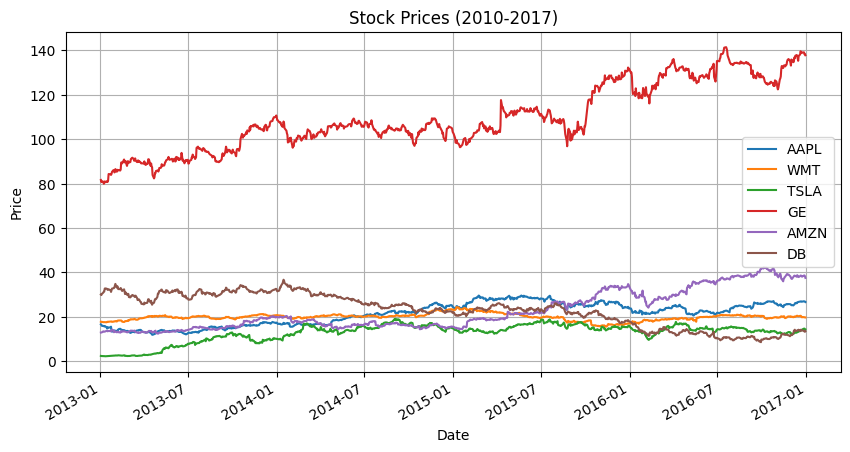

,AAPL,WMT,TSLA,GE,AMZN,DB
Date,,,,,,
2013-01-03 00:00:00-05:00,-0.012703,-0.006375,-0.016826,-0.011310,0.004537,-0.007289
2013-01-04 00:00:00-05:00,-0.028249,0.003772,-0.010699,0.004728,0.002589,0.015835
2013-01-07 00:00:00-05:00,-0.005900,-0.009603,-0.001746,-0.003307,0.035295,0.020517
2013-01-08 00:00:00-05:00,0.002687,0.002774,-0.019407,-0.010945,-0.007778,0.013377
2013-01-09 00:00:00-05:00,-0.015752,-0.000292,-0.001188,0.002389,-0.000113,0.001897
...,...,...,...,...,...,...
2016-12-23 00:00:00-05:00,0.001976,-0.000719,0.023188,0.001884,-0.007532,0.004843
2016-12-27 00:00:00-05:00,0.006331,0.002298,0.028602,0.000627,0.014113,-0.014054
2016-12-28 00:00:00-05:00,-0.004273,-0.005611,0.000956,-0.006289,0.000946,-0.024802


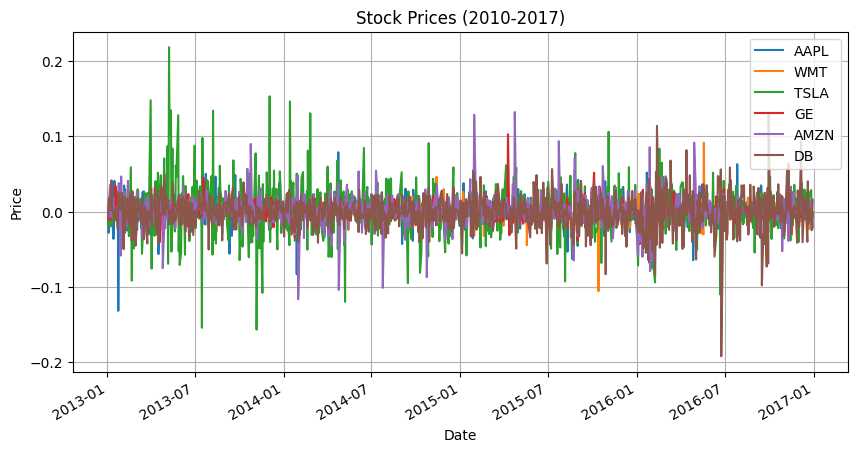

show means


AAPL    0.118701
WMT     0.025857
TSLA    0.450183
GE      0.131100
AMZN    0.267670
DB     -0.200725
dtype: float64

show covariance matrix


,AAPL,WMT,TSLA,GE,AMZN,DB
AAPL,0.063879,0.008260,0.021232,0.013615,0.017642,0.019994
WMT,0.008260,0.028308,0.010607,0.009548,0.009364,0.012890
TSLA,0.021232,0.010607,0.243798,0.018141,0.043593,0.031897
GE,0.013615,0.009548,0.018141,0.032168,0.017155,0.028071
AMZN,0.017642,0.009364,0.043593,0.017155,0.093966,0.028924
DB,0.019994,0.012890,0.031897,0.028071,0.028924,0.127733


(np.float64(0.15886694162155696), np.float64(0.17160840285713969))


In [90]:
if __name__ == "__main__":
    data = download_data()
    display(data)
    show_data(data)
    display(calculate_returns(data))
    return_ = calculate_returns(data)
    show_data(return_)
    show_statistics(return_)
    print(show_mean_and_variance(return_, weight))

In [95]:
#THIS IF FOR EFFICIENT FRONTIER
def generate_portfolio(returns):
    portfolio_means = []
    portfolio_risk = []
    portfolio_weight = []
    
    for _ in range(NUM_PORTFOLIO):
        w = np.random.random(len(stocks))
        w /= np.sum(w)
        mean, volatility = show_mean_and_variance(return_, w)
        portfolio_weight.append(w)
        portfolio_means.append(mean)
        portfolio_risk.append(volatility)
        
        
    return np.array(portfolio_weight), np.array(portfolio_means), np.array(portfolio_risk)

def show_portfolio(returns, volatility):
    plt.figure(figsize=(10, 6))
    plt.scatter(volatility, returns, c = returns/volatility, marker = 'o') # c as color
    plt.grid(True)
    plt.ylabel('Expected Return')
    plt.xlabel('Expected Volatility')
    plt.colorbar(label = 'Sharpe Ratio')
    plt.show()
        

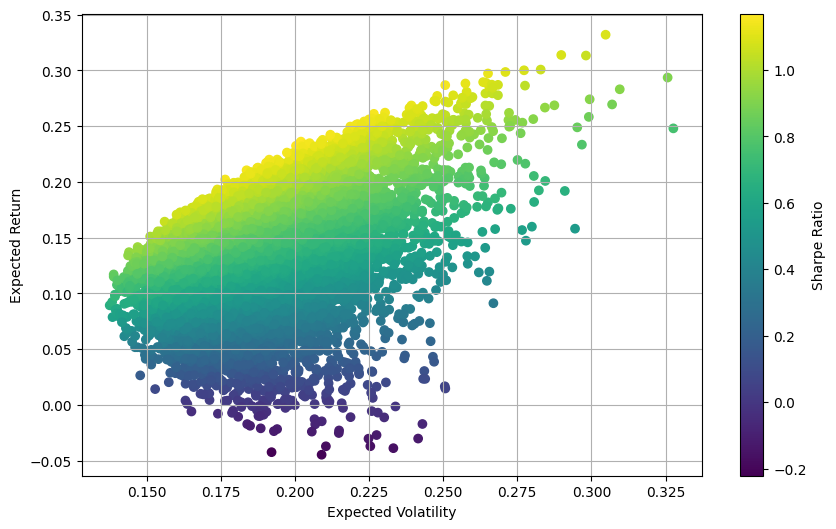

In [ ]:
if __name__ == "__main__":
    data = download_data()
    return_ = calculate_returns(data)
    pweight, pmeans, prisk = generate_portfolio(return_)
    show_portfolio(pmeans, prisk)
    #the efficient frontier is colored yellow here.
    

In [ ]:
#THIS IS FOR FINDINF THE MOST OPTIMAL PORTFOLIO WITH HIGH SHARPE RATIO

def statistics(weight, returns, risk_free_rate = 0):
    portfolio_return = np.sum(returns.mean() * weight) * NUM_TRADING_DAY
    portfolio_volatility = np.sqrt( np.dot(weight.T, np.dot(returns.cov() * NUM_TRADING_DAY, weight)))
    
    return np.array([portfolio_return, portfolio_volatility, (portfolio_return - risk_free_rate)/ portfolio_volatility])

#scipy optimize module can find the minimum of a given function
#the maximum of a f(x) is the minimum of the -f(x)
def min_function_sharpe(weight, returns):
    return -statistics(weight, returns)[2]

#what are the constraints? the sum of weight = 1
#if sum w - 1 = 0 then this is the functio to minimize
#CREATE MARKET ALLOCATION LINE?
def optimize_portfolio(weight, returns):
    constraints = {"type" : "eq", "fun" : lambda x: np.sum(x) - 1}
    #the weights can be 1 at most: 1 when 100% is invested into a single stock
    bounds = tuple((0, 1) for _ in range(len(stocks)))
    return optimization.minimize(fun = min_function_sharpe, x0 = weight[0], args = returns,
                          method= "SLSQP", bounds= bounds, constraints= constraints) # we shall explain the optimization part
    
    
def print_optimal_portfolio(optimum, returns):
    print("Optimal portfolio: ", optimum['x'].round(3))
    print("Expected return, volatility and Sharpe ratio: ",
          statistics(optimum['x'].round(3), returns))
    
    
def show_optimal_portfolio(opt, rets, portfolio_rets, portfolio_vols):
    plt.figure(figsize=(10, 6))
    plt.scatter(portfolio_vols, portfolio_rets, c = portfolio_rets/portfolio_vols, marker = 'o') # c as color
    plt.grid(True)
    plt.ylabel('Expected Return')
    plt.xlabel('Expected Volatility')
    plt.colorbar(label = 'Sharpe Ratio')
    plt.plot(statistics(opt['x'], rets)[1], statistics(opt['x'], rets)[0], "g*", markersize = 20) #put a green star on the maximum Sharpe Ratio
    plt.show()
    

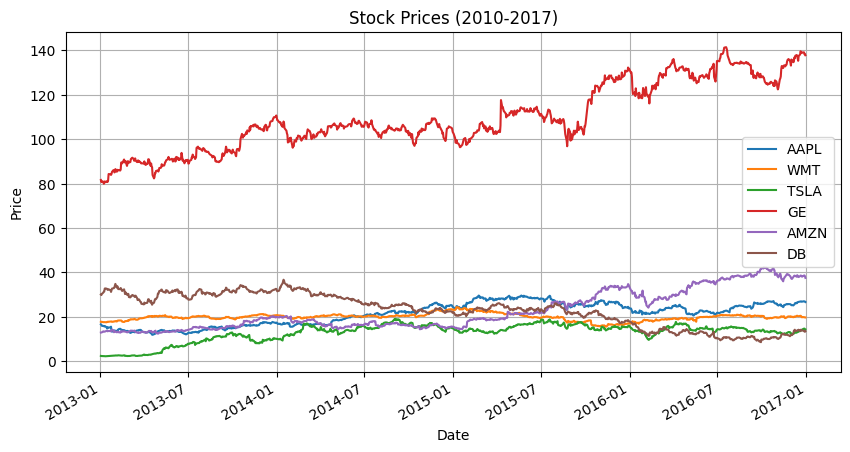

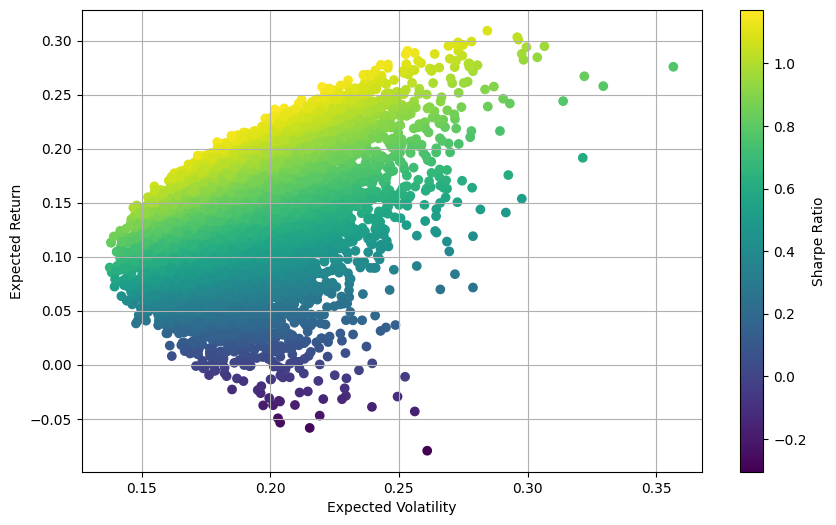

Optimal portfolio:  [0.081 0.    0.232 0.383 0.304 0.   ]
Expected return, volatility and Sharpe ratio:  [0.24564007 0.2069379  1.1870231 ]


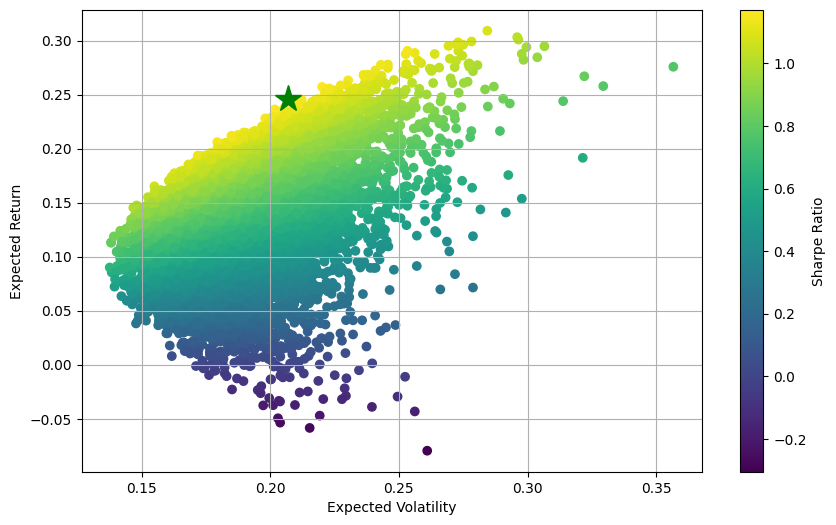

In [102]:
if __name__ == "__main__":
    dataset = download_data()
    show_data(dataset)
    log_daily_returns = calculate_returns(dataset)
    
    pweight, pmeans, prisk = generate_portfolio(log_daily_returns)
    show_portfolio(pmeans, prisk)
    optimum = optimize_portfolio(pweight, log_daily_returns)
    print_optimal_portfolio(optimum, log_daily_returns)
    show_optimal_portfolio(optimum, log_daily_returns, pmeans, prisk)
    

in this case, we got the Sharpe ratio at the maximum Sharpe ratio to me more than 1 hence it is a good investment

In [ ]:
#